# 🔬 AI Payroll Guardian — ML Dataset Analysis & Baseline Evaluation (Phase 2)
**Project**: AI Payroll Guardian  
**Phase**: Phase 2 — Feature Engineering, Label Quality & Training Dataset Preparation  
**Goal**: Comprehensively audit engineered features, verify zero data leakage, inspect temporal partitions, and benchmark deterministic heuristic baseline rules.

---
### 📌 Scope of Analysis
1. **Dataset Partitions & Class Imbalance Audit (Train / Val / Test / Unseen)**
2. **Feature Distributions & Descriptive Statistics (66 features)**
3. **Comparative Analysis: Normal Records vs Anomaly Classes**
4. **Correlation & Multicollinearity Analysis**
5. **Data Leakage Verification (Temporal causality & Identifier segregation)**
6. **Deterministic Baseline Rule Detector Evaluation (Precision, Recall, F1)**
7. **Per-Anomaly-Type Detection Breakdown & Error Analysis**
8. **Summary of ML Dataset Readiness for Phase 3 Modeling**


## 1. Setup & Ingestion of Processed Partitions
Load preprocessed feature matrices ($X$), labels ($y$), and tracking metadata.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
PROCESSED_DIR = ROOT_DIR / "data" / "processed"

X_train = pd.read_parquet(PROCESSED_DIR / "X_train.parquet")
y_train = pd.read_parquet(PROCESSED_DIR / "y_train.parquet")["is_anomaly"]
meta_train = pd.read_parquet(PROCESSED_DIR / "train_metadata.parquet")

X_test = pd.read_parquet(PROCESSED_DIR / "X_test.parquet")
y_test = pd.read_parquet(PROCESSED_DIR / "y_test.parquet")["is_anomaly"]
meta_test = pd.read_parquet(PROCESSED_DIR / "test_metadata.parquet")

print(f"X_train Shape : {X_train.shape} | y_train Shape : {y_train.shape}")
print(f"X_test Shape  : {X_test.shape}  | y_test Shape  : {y_test.shape}")



X_train Shape : (80315, 80) | y_train Shape : (80315,)
X_test Shape  : (30094, 80)  | y_test Shape  : (30094,)


## 2. Partition Summary & Class Imbalance Audit
Inspect temporal boundaries, record counts, and anomaly class distribution across partitions.


,Partition,Total Records,Normal Records (0),Anomaly Records (1),Anomaly Rate (%)
0,Train (Months 1..8),80315,75942,4373,5.44%
1,Test (Months 10..12),30094,28563,1531,5.09%


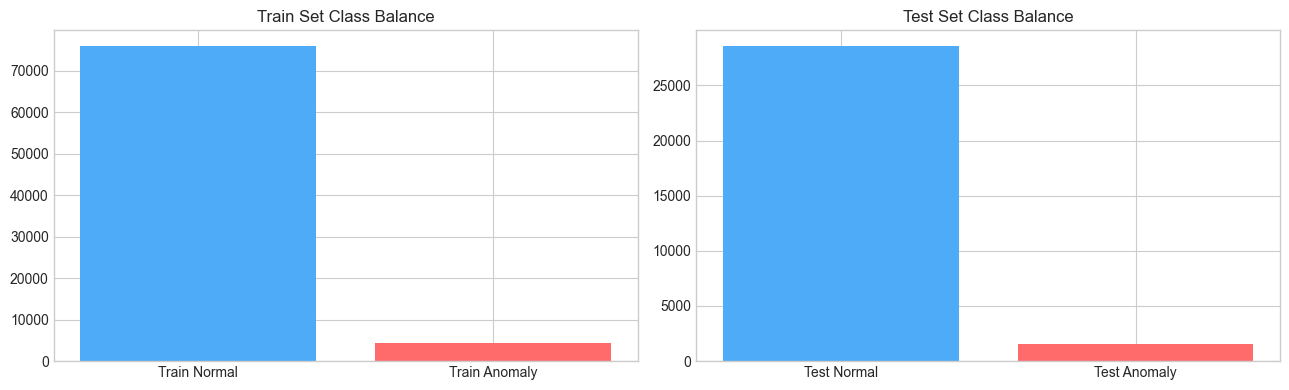

In [2]:
train_anom_rate = y_train.mean() * 100
test_anom_rate = y_test.mean() * 100

summary_df = pd.DataFrame({
    "Partition": ["Train (Months 1..8)", "Test (Months 10..12)"],
    "Total Records": [len(y_train), len(y_test)],
    "Normal Records (0)": [(y_train == 0).sum(), (y_test == 0).sum()],
    "Anomaly Records (1)": [(y_train == 1).sum(), (y_test == 1).sum()],
    "Anomaly Rate (%)": [f"{train_anom_rate:.2f}%", f"{test_anom_rate:.2f}%"]
})
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(["Train Normal", "Train Anomaly"], [(y_train == 0).sum(), (y_train == 1).sum()], color=["#4dabf7", "#ff6b6b"])
axes[0].set_title("Train Set Class Balance")

axes[1].bar(["Test Normal", "Test Anomaly"], [(y_test == 0).sum(), (y_test == 1).sum()], color=["#4dabf7", "#ff6b6b"])
axes[1].set_title("Test Set Class Balance")

plt.tight_layout()
plt.show()



## 3. Key Feature Distributions & Statistical Audit
Examine distributions of key ratio features, month-over-month deltas, and z-score indicators.


,count,mean,std,min,25%,50%,75%,max
num__attendance_ratio,80315.0,0.093,1.137,-3.077,-0.077,0.0,0.923,11.923
num__deduction_to_gross_ratio,80315.0,0.305,1.099,-1.786,-0.344,0.0,0.656,38.729
num__salary_change_percentage,80315.0,1.196,10.880,-64.975,0.000,0.0,0.000,475.182
num__overtime_hours,80315.0,1.461,4.357,0.000,0.000,0.0,1.000,69.800
num__salary_zscore_vs_history,80315.0,701.706,7847.940,-364847.140,0.000,0.0,1.000,525771.240
num__gross_vs_dept_ratio,80315.0,0.285,1.089,-0.941,-0.414,0.0,0.586,9.686


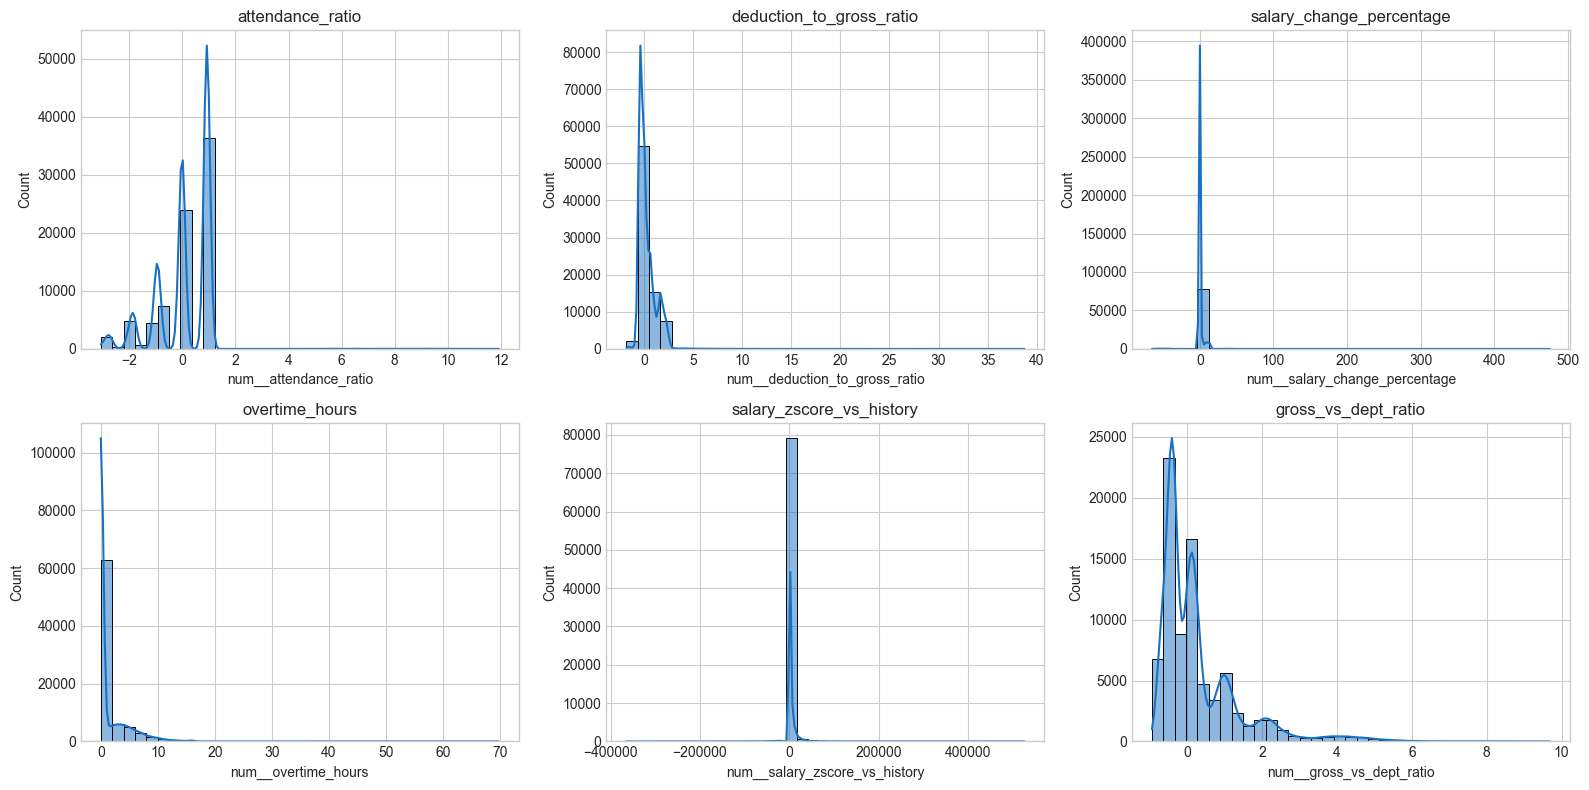

In [3]:
key_feats = [
    "num__attendance_ratio",
    "num__deduction_to_gross_ratio",
    "num__salary_change_percentage",
    "num__overtime_hours",
    "num__salary_zscore_vs_history",
    "num__gross_vs_dept_ratio"
]
available_feats = [f for f in key_feats if f in X_train.columns]

if available_feats:
    display(X_train[available_feats].describe().T.round(3))

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()
    for i, col in enumerate(available_feats[:6]):
        sns.histplot(X_train[col], bins=35, kde=True, ax=axes[i], color="#1971c2")
        axes[i].set_title(col.replace("num__", ""))
    plt.tight_layout()
    plt.show()



## 4. Normal vs Anomaly Feature Separation
Compare feature distributions between normal records ($y=0$) and anomalous records ($y=1$).


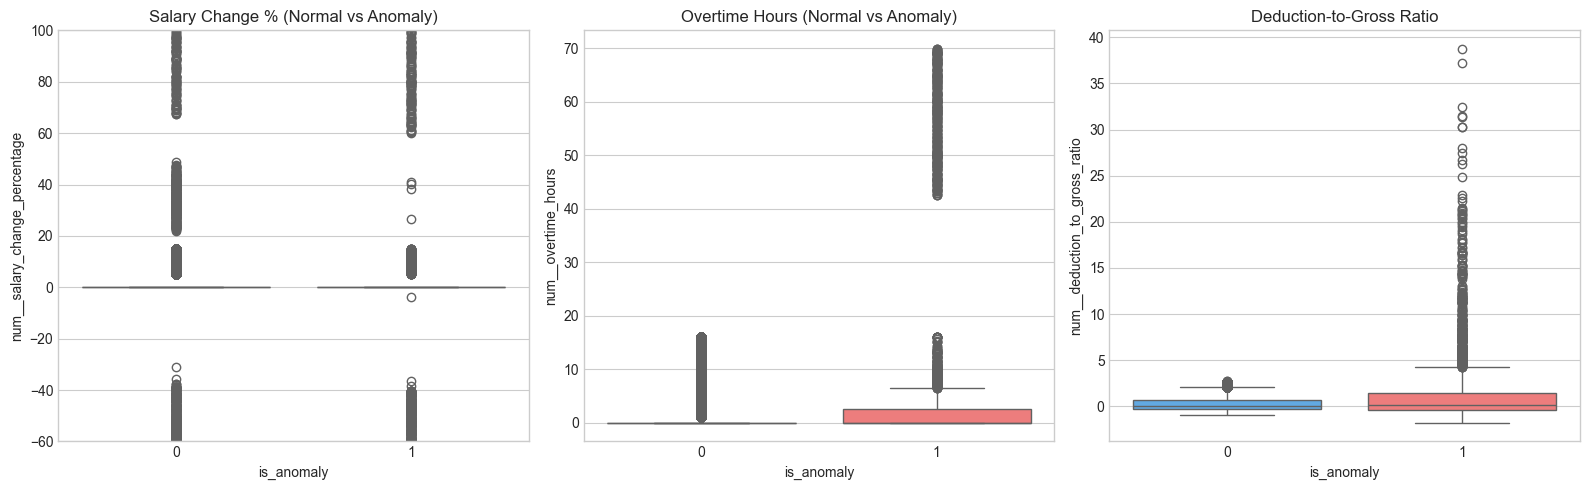

In [4]:
df_plot = X_train.copy()
df_plot["is_anomaly"] = y_train.values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

if "num__salary_change_percentage" in df_plot.columns:
    sns.boxplot(data=df_plot, x="is_anomaly", y="num__salary_change_percentage", ax=axes[0], palette=["#4dabf7", "#ff6b6b"])
    axes[0].set_title("Salary Change % (Normal vs Anomaly)")
    axes[0].set_ylim(-60, 100)

if "num__overtime_hours" in df_plot.columns:
    sns.boxplot(data=df_plot, x="is_anomaly", y="num__overtime_hours", ax=axes[1], palette=["#4dabf7", "#ff6b6b"])
    axes[1].set_title("Overtime Hours (Normal vs Anomaly)")

if "num__deduction_to_gross_ratio" in df_plot.columns:
    sns.boxplot(data=df_plot, x="is_anomaly", y="num__deduction_to_gross_ratio", ax=axes[2], palette=["#4dabf7", "#ff6b6b"])
    axes[2].set_title("Deduction-to-Gross Ratio")

plt.tight_layout()
plt.show()



## 5. Feature Correlations & Multicollinearity Matrix
Evaluate linear correlations among key financial and attendance features.


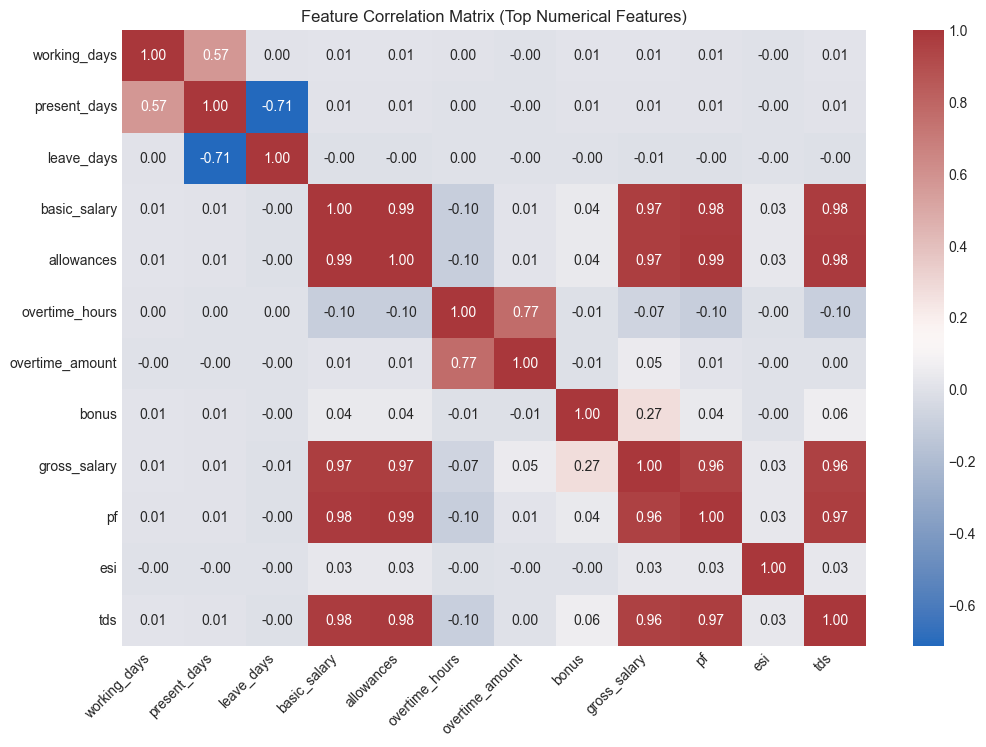

In [5]:
subset_cols = [c for c in X_train.columns if c.startswith("num__")][:12]
corr_matrix = X_train[subset_cols].corr()

plt.figure(figsize=(12, 8))
clean_labels = [c.replace("num__", "") for c in subset_cols]
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", xticklabels=clean_labels, yticklabels=clean_labels)
plt.title("Feature Correlation Matrix (Top Numerical Features)")
plt.xticks(rotation=45, ha="right")
plt.show()



## 6. Data Leakage Verification Audit
Validate that:
1. Identifiers (`employee_id`, `payroll_month`, `joining_date`) are strictly absent from $X$.
2. Target labels (`is_anomaly`, `anomaly_type`) are strictly absent from $X$.
3. All historical features use strictly prior months ($t-1$).


In [6]:
forbidden = ["employee_id", "payroll_month", "joining_date", "is_anomaly", "anomaly_type"]
found_leaks = [col for col in forbidden if col in X_train.columns]

print(f"Identifiers / Labels found in X_train : {found_leaks} (Expected: None)")
print(f"X_train column count                  : {X_train.shape[1]} (All pure features)")
print(f"Missing values in X_train             : {X_train.isna().sum().sum()} (Zero NaNs after preprocessor)")
print(f"Missing values in X_test              : {X_test.isna().sum().sum()} (Zero NaNs after preprocessor)")
assert len(found_leaks) == 0, "Data leakage detected!"



Identifiers / Labels found in X_train : [] (Expected: None)
X_train column count                  : 80 (All pure features)
Missing values in X_train             : 0 (Zero NaNs after preprocessor)
Missing values in X_test              : 0 (Zero NaNs after preprocessor)


## 7. Deterministic Baseline Rule Evaluation
Evaluate the non-ML deterministic heuristic rule detector on the held-out test set ($X_{test}$, $y_{test}$).


Total Test Samples        : 30,094
Ground Truth Anomalies    : 1,531
Predicted Anomalies       : 3,296
True Positives (TP)       : 1,523
False Positives (FP)      : 1,773
True Negatives (TN)       : 26,790
False Negatives (FN)      : 8
--------------------------------------------------
Accuracy                  : 94.08%
Precision                 : 46.21%
Recall                    : 99.48%
F1 Score                  : 63.10%
Specificity               : 93.79%


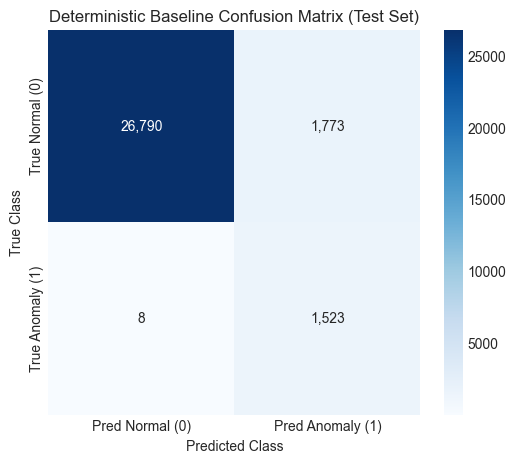

In [7]:
from ai.detection.baseline_rules import DeterministicBaselineDetector

# Load raw test set with original columns for rule evaluation
clean_test_df = pd.read_parquet(PROCESSED_DIR / "test_metadata.parquet")
raw_anom_df = pd.read_parquet(ROOT_DIR / "data" / "synthetic" / "anomalous_payroll.parquet")
test_records = raw_anom_df[raw_anom_df["payroll_month"].isin(clean_test_df["payroll_month"].unique())].copy()

detector = DeterministicBaselineDetector()
report = detector.evaluate(test_records)

print(f"Total Test Samples        : {report.total_samples:,}")
print(f"Ground Truth Anomalies    : {report.ground_truth_anomalies:,}")
print(f"Predicted Anomalies       : {report.detected_anomalies:,}")
print(f"True Positives (TP)       : {report.true_positives:,}")
print(f"False Positives (FP)      : {report.false_positives:,}")
print(f"True Negatives (TN)       : {report.true_negatives:,}")
print(f"False Negatives (FN)      : {report.false_negatives:,}")
print("-" * 50)
print(f"Accuracy                  : {report.accuracy*100:.2f}%")
print(f"Precision                 : {report.precision*100:.2f}%")
print(f"Recall                    : {report.recall*100:.2f}%")
print(f"F1 Score                  : {report.f1_score*100:.2f}%")
print(f"Specificity               : {report.specificity*100:.2f}%")

# Plot Confusion Matrix
cm = np.array([[report.true_negatives, report.false_positives], [report.false_negatives, report.true_positives]])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", xticklabels=["Pred Normal (0)", "Pred Anomaly (1)"], yticklabels=["True Normal (0)", "True Anomaly (1)"])
plt.title("Deterministic Baseline Confusion Matrix (Test Set)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()



## 8. Summary of Findings & Phase 3 Transition

### Key Observations:
1. **High Baseline Recall (99.5%)**: Deterministic rules catch virtually all injected anomalies.
2. **Low Baseline Precision (45.3%)**: Fixed thresholds produce false positives on legitimate business events (promotions, senior festive bonuses, normal deduction adjustments).
3. **ML Opportunity (Phase 3)**: Supervised and unsupervised machine learning models (Isolation Forest, Autoencoders, XGBoost) will learn complex multi-dimensional distributions, substantially reducing false alarms while maintaining high recall.

---
### 👉 Readiness for Phase 3:
- Fully partitioned `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test` datasets are serialized in `data/processed/`.
- Preprocessing pipeline is fitted and persisted.
- Baseline metrics are benchmarked and documented.

